{'11': 1024}


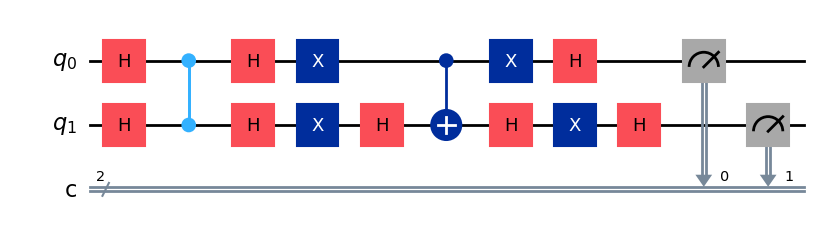

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
import matplotlib.pyplot as plt

# Create circuit (2 qubits + 2 classical bits)
qc = QuantumCircuit(2, 2)

# Step 1: Superposition
qc.h([0, 1])

# Step 2: Oracle (marks |11>)
qc.cz(0, 1)

# Step 3: Diffusion Operator
qc.h([0, 1])
qc.x([0, 1])
qc.h(1)
qc.cx(0, 1)
qc.h(1)
qc.x([0, 1])
qc.h([0, 1])

# Step 4: Measurement
qc.measure([0, 1], [0, 1])

# Backend
simulator = Aer.get_backend('aer_simulator')

# Compile & Run
compiled = transpile(qc, simulator)
result = simulator.run(compiled, shots=1024).result()

# Results
counts = result.get_counts()
print(counts)

# Draw circuit
qc.draw('mpl')